# Load Data

In [1]:
TABLE = "price_features"
CALENDAR = "no_calendar"

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [4]:
df = pull_calendar_table(
    table_name = TABLE,
    calendar = CALENDAR
)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table


In [5]:
df.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'daily_return_no_calendar', 'log_return_no_calendar',
       'cumulative_returns_no_calendar', 'rolling_7d_return_no_calendar',
       'rolling_30d_return_no_calendar', 'lag_1_return_no_calendar',
       'lag_5_return_no_calendar', 'moving_avg_20_no_calendar',
       'moving_avg_50_no_calendar', 'price_vs_ma20_no_calendar',
       'relative_volume_no_calendar', 'rolling_30d_volatility_no_calendar',
       'drawdown_no_calendar', 'target_next_day_return_no_calendar',
       'target_direction_no_calendar'],
      dtype='str')

In [6]:
table_count = 0
graph_count = 0
matrix_count = 0

# Inspect Target Next Day Returns

In [7]:
df_1 = df.copy()

ticker = "ticker"
target_col = f"target_next_day_return_{CALENDAR}"

ticker_summary_rows = []

for asset, group in df_1.groupby(ticker):
    tndr_ticker_summary = group[target_col].agg([
        "mean",
        "median",
        "std",
        "min",
        "max",
        "skew",
        "kurt"
    ])

    tndr_ticker_summary.loc["p1"] = group[target_col].quantile(0.01)
    tndr_ticker_summary.loc["p99"] = group[target_col].quantile(0.99)

    tndr_ticker_summary = tndr_ticker_summary.to_frame().T
    tndr_ticker_summary.index = [asset]

    ticker_summary_rows.append(tndr_ticker_summary)

tndr_ticker_summary_df = pd.concat(ticker_summary_rows)

table_count += 1
print(f"Table {table_count}:")

display(tndr_ticker_summary_df.sort_values("skew"))

Table 1:


,mean,median,std,min,max,skew,kurt,p1,p99
GLD,0.000564,0.000619,0.010588,-0.102742,0.063587,-0.636367,7.305299,-0.030544,0.027924
SPY,0.000614,0.000900,0.012091,-0.109424,0.105019,-0.294439,13.116533,-0.033655,0.028521
NKE,0.000087,0.000000,0.021387,-0.199809,0.155314,-0.268748,12.821108,-0.057467,0.055998
TLT,-0.000013,0.000123,0.009738,-0.066683,0.075196,0.161246,5.043367,-0.023337,0.024603
MU,0.002091,0.001012,0.033101,-0.198186,0.192916,0.175578,3.593143,-0.079828,0.097890
SNDK,0.014118,0.008176,0.064327,-0.213016,0.286494,0.345475,2.506943,-0.155648,0.174566
RPI.L,0.002499,-0.001033,0.047394,-0.139640,0.470910,3.267675,26.666113,-0.095784,0.149991


# Inspect Target Direction

In [8]:
df_2 = df.copy()

date="date"
ticker="ticker"
target_direction = f"target_direction_{CALENDAR}"
target_return = f"target_next_day_return_{CALENDAR}"

target_direction_summary_df = pd.DataFrame({
    "No. Distinct Classes": [df_2[target_direction].nunique()],
    "No. Missing Targets": [df_2[target_direction].isna().sum()],
    "No. Zero Target Returns": [(df_2[target_return] == 0).sum()],
    "Percent Zero Target Returns": [(df_2[target_return] ==0).mean()*100]
})

table_count += 1
print(f"Table {table_count}:")

display(target_direction_summary_df.style.hide(axis="index"))

zero_dates = df_2.loc[df_2[target_return] == 0, [date, ticker, target_return, target_direction]]

table_count += 1
print(f"Table {table_count}:")

display(zero_dates.groupby(ticker).head(1).style.hide(axis="index"))

Table 2:


No. Distinct Classes,No. Missing Targets,No. Zero Target Returns,Percent Zero Target Returns
2,7,42,0.364141


Table 3:


date,ticker,target_next_day_return_no_calendar,target_direction_no_calendar
2018-03-09 00:00:00,GLD,0.000000,0
2018-04-10 00:00:00,MU,0.000000,0
2018-11-13 00:00:00,NKE,0.000000,0
2024-07-17 00:00:00,RPI.L,0.000000,0
2018-05-07 00:00:00,SPY,0.000000,0
2018-03-14 00:00:00,TLT,0.000000,0


# Class Balance for Direction Target

In [9]:
df_3 = df.copy()

ticker = "ticker"
target_direction = f"target_direction_{CALENDAR}"
target_return = f"target_next_day_return_{CALENDAR}"

ticker_summary_rows = []

for asset, group in df_3.groupby(ticker):
    ticker_summary_row = pd.DataFrame({
        "Up Days": [(group[target_direction] == 1).sum()],
        "Down Days": [(group[target_direction] ==0).sum()],
        "Total Observations": group[target_direction].count()
    })

    ticker_summary_row.index = [asset]

    ticker_summary_rows.append(ticker_summary_row)

ticker_summary_df = pd.concat(ticker_summary_rows)

table_count += 1
print(f"Table {table_count}:")

display(ticker_summary_df)

Table 4:


,Up Days,Down Days,Total Observations
GLD,1148,985,2133
MU,1112,1021,2133
NKE,1065,1068,2133
RPI.L,246,272,518
SNDK,196,148,344
SPY,1181,952,2133
TLT,1075,1058,2133


# Percentage of Up vs Down Days

In [10]:
df_4 = df.copy()

ticker = "ticker"
target_direction = f"target_direction_{CALENDAR}"
target_return = f"target_next_day_return_{CALENDAR}"

ticker_summary_rows = []

for asset, group in df_4.groupby(ticker):
    ticker_summary_row = pd.DataFrame({
        "Up Days (%)": [(group[target_direction] ==1).mean()*100],
        "Down Days (%)": [(group[target_direction] ==0).mean()*100],
        "Observations": group[target_direction].count()
    })

    ticker_summary_row.index = [asset]

    ticker_summary_rows.append(ticker_summary_row)

ticker_summary_df = pd.concat(ticker_summary_rows)

table_count += 1
print(f"Table {table_count}:")

display(ticker_summary_df.sort_values("Up Days (%)").round(2))

Table 5:


,Up Days (%),Down Days (%),Observations
RPI.L,47.49,52.51,518
NKE,49.93,50.07,2133
TLT,50.40,49.60,2133
MU,52.13,47.87,2133
GLD,53.82,46.18,2133
SPY,55.37,44.63,2133
SNDK,56.98,43.02,344


# Target Noise

Graph 1:


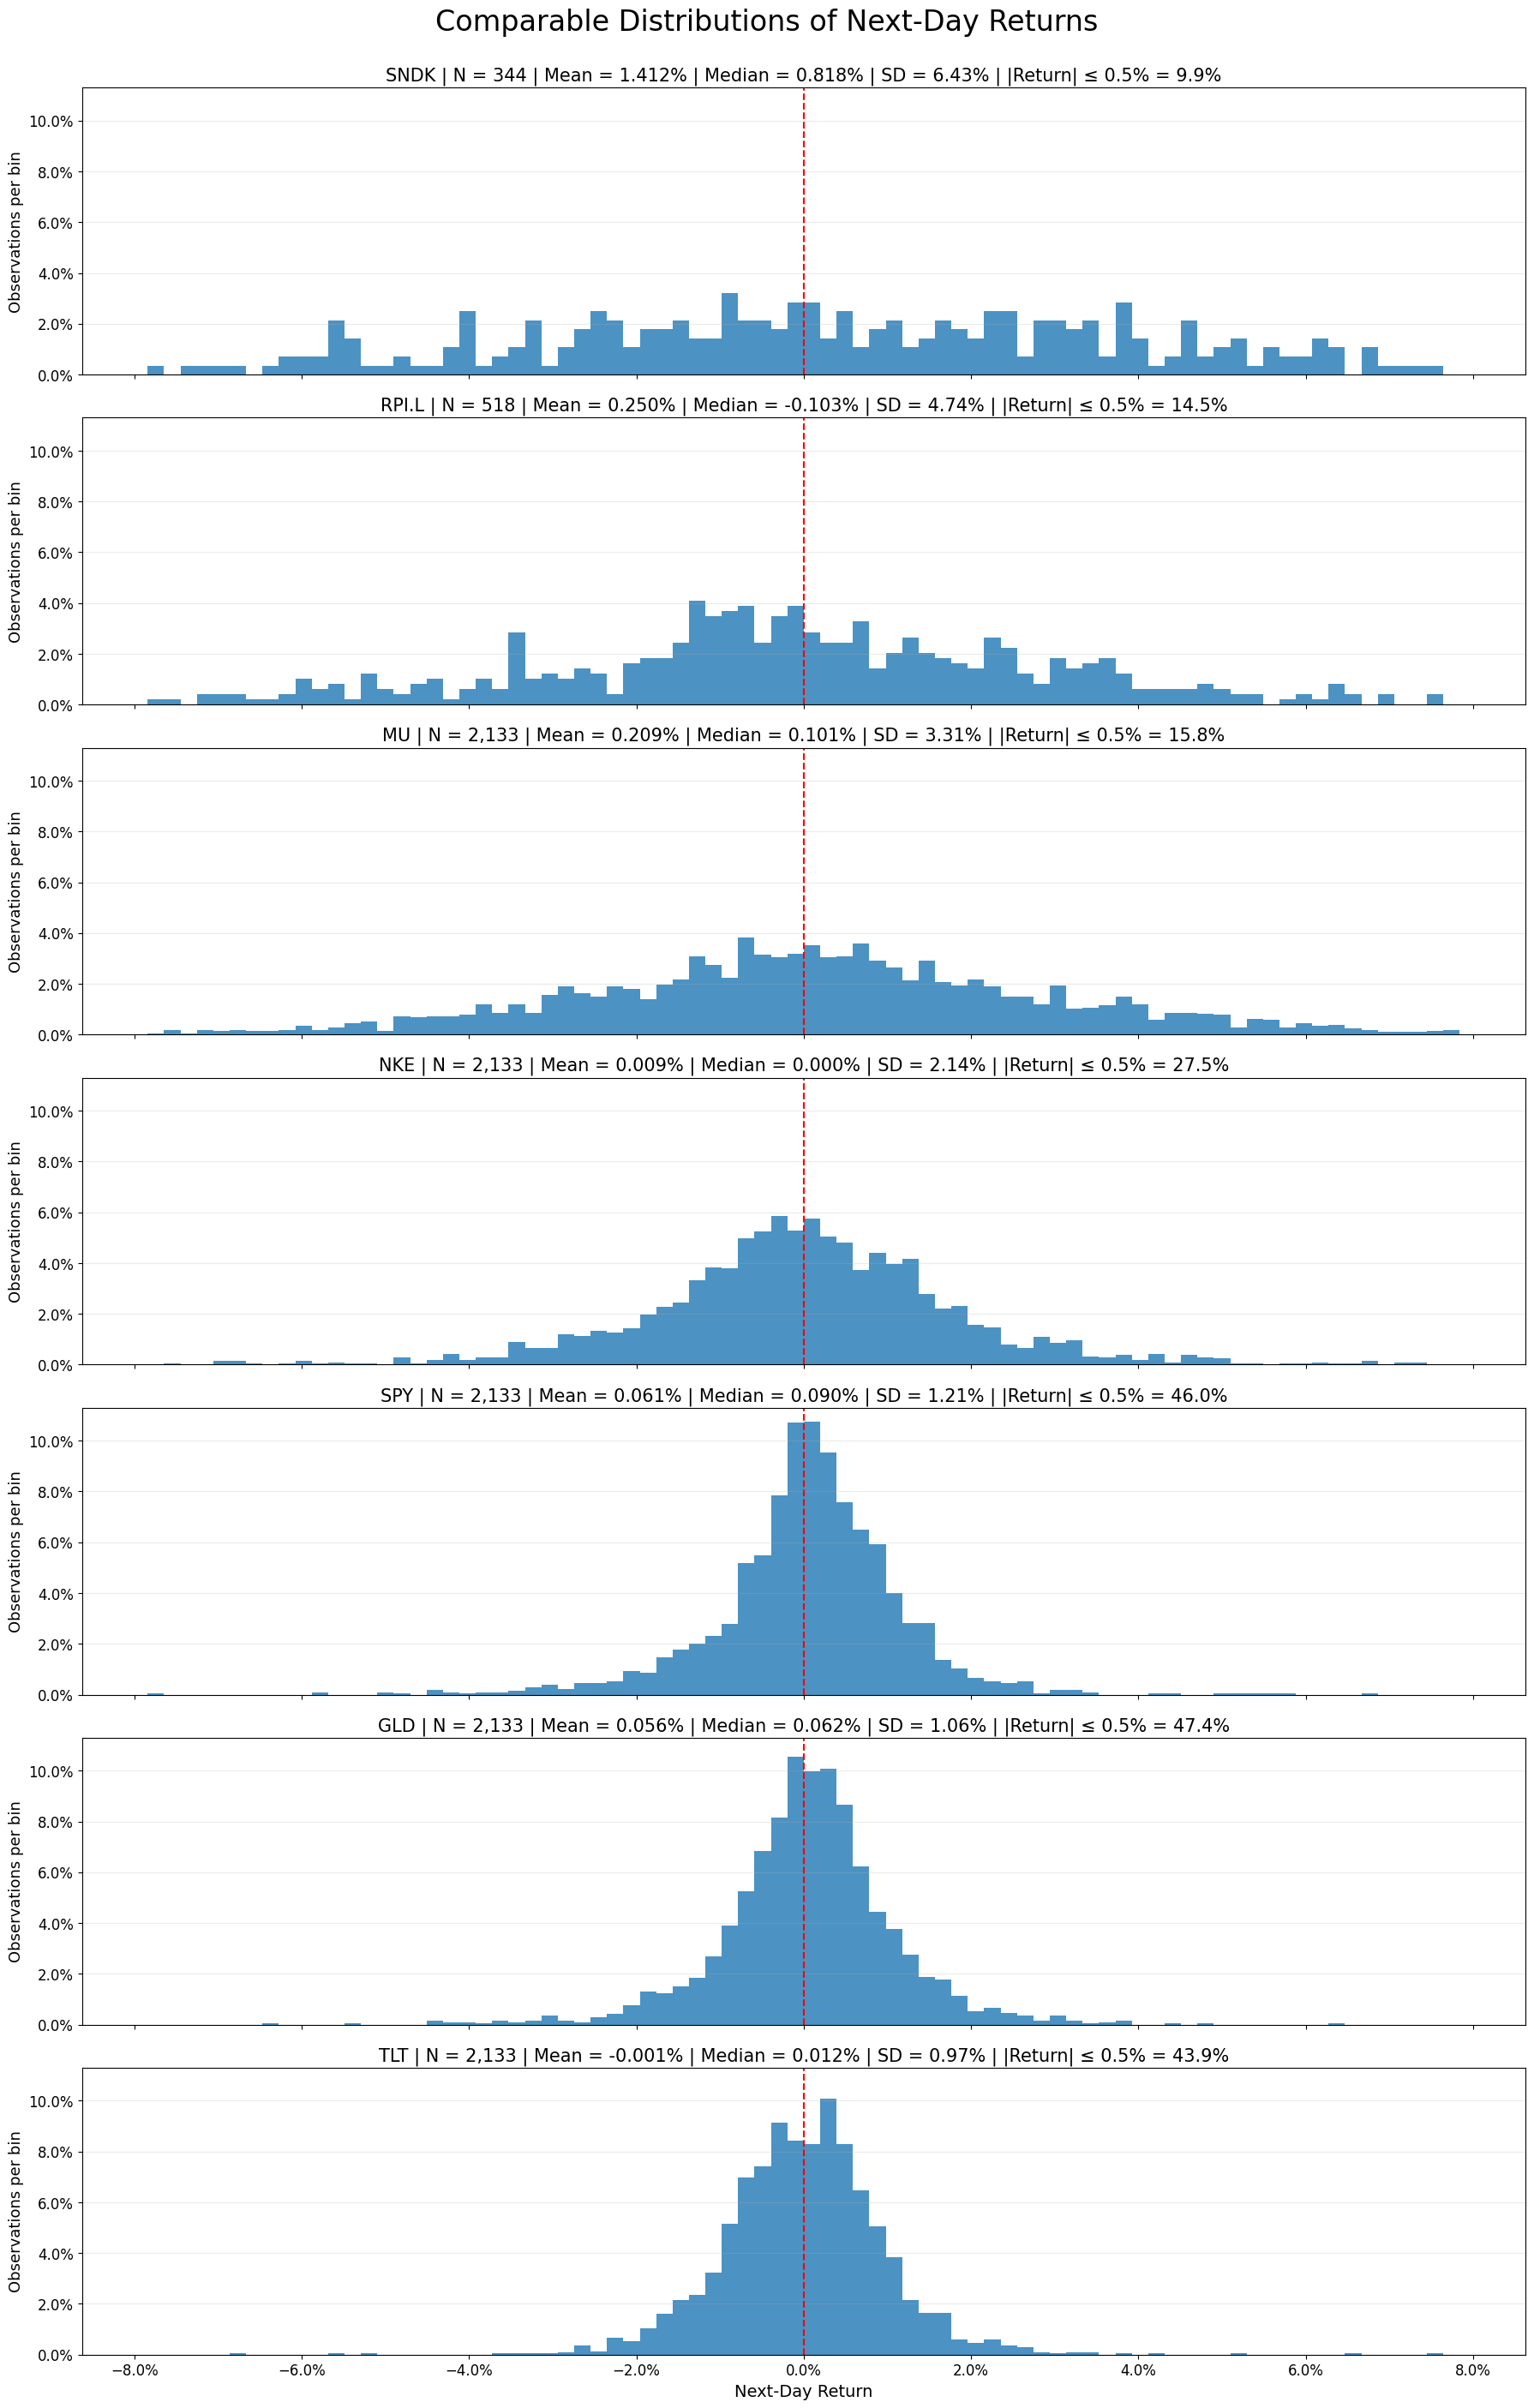

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df_5 = df.copy()

ticker_col = "ticker"
target_col = f"target_next_day_return_{CALENDAR}"

# Keep only the columns needed for this analysis.
plot_data = (
    df_5[[ticker_col, target_col]]
    .dropna()
    .copy()
)

# ------------------------------------------------------------------
# 1. Calculate robust distribution width for ordering the tickers
# ------------------------------------------------------------------

distribution_stats = (
    plot_data.groupby(ticker_col)[target_col]
    .agg(
        q01=lambda s: s.quantile(0.01),
        q99=lambda s: s.quantile(0.99),
        mean="mean",
        median="median",
        std="std",
        count="size"
    )
)

distribution_stats["robust_width"] = (
    distribution_stats["q99"] -
    distribution_stats["q01"]
)

ordered_tickers = (
    distribution_stats
    .sort_values("robust_width", ascending=False)
    .index
    .tolist()
)

# ------------------------------------------------------------------
# 2. Create one common symmetric x-axis
# ------------------------------------------------------------------

global_q01 = plot_data[target_col].quantile(0.01)
global_q99 = plot_data[target_col].quantile(0.99)

global_x_limit = max(
    abs(global_q01),
    abs(global_q99)
)

# Every histogram uses exactly the same bins.
bin_edges = np.linspace(
    -global_x_limit,
    global_x_limit,
    81
)

# ------------------------------------------------------------------
# 3. Create comparable percentage histograms
# ------------------------------------------------------------------

n_rows = len(ordered_tickers)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=1,
    figsize=(18, 4 * n_rows),
    sharex=True,
    sharey=True
)

axes = np.atleast_1d(axes).flatten()

for ax, asset in zip(axes, ordered_tickers):

    all_returns = (
        plot_data.loc[
            plot_data[ticker_col] == asset,
            target_col
        ]
        .to_numpy()
    )

    # Plot the common central range.
    displayed_returns = all_returns[
        (all_returns >= -global_x_limit) &
        (all_returns <= global_x_limit)
    ]

    # Convert each bin height into a percentage of displayed observations.
    weights = np.full(
        displayed_returns.size,
        100 / displayed_returns.size
    )

    ax.hist(
        displayed_returns,
        bins=bin_edges,
        weights=weights,
        alpha=0.8
    )

    ax.axvline(
        0,
        linestyle="--",
        color="red",
        linewidth=1.5,
        label="Zero return"
    )

    mean_return = np.mean(all_returns)
    median_return = np.median(all_returns)
    standard_deviation = np.std(all_returns, ddof=1)

    near_zero_percentage = (
        np.mean(np.abs(all_returns) <= 0.005) * 100
    )

    ax.set_title(
        f"{asset} | "
        f"N = {len(all_returns):,} | "
        f"Mean = {mean_return:.3%} | "
        f"Median = {median_return:.3%} | "
        f"SD = {standard_deviation:.2%} | "
        f"|Return| ≤ 0.5% = {near_zero_percentage:.1f}%",
        fontsize=15
    )

    ax.set_ylabel(
        "Observations per bin",
        fontsize=13
    )

    ax.tick_params(
        axis="both",
        labelsize=12
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=100)
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

axes[-1].set_xlabel(
    "Next-Day Return",
    fontsize=14
)

axes[-1].xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

fig.suptitle(
    "Comparable Distributions of Next-Day Returns",
    fontsize=24,
    y=1.002
)

fig.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()